# Model Improvement and Data Augmentation (Milestone-3)

In this notebook, we improve the segmentation model performance by:

- **Integrating Production Modules**: Importing data, model, and training logic from `src/`.
- **Advanced Augmentation**: Using **Albumentations** for robust training.
- **Optimized UNet**: Using `ImprovedUNet` with BatchNorm and Dropout.
- **Combined Loss**: Training with **BCEWithLogitsLoss + DiceLoss** for better overlap.
- **Learning Rate Scheduler**: Using `ReduceLROnPlateau` for stable convergence.

This milestone represents the final optimization for the VisionExtract model.

## 1. Import Libraries

Import required libraries for dataset loading, model training, augmentation, and visualization.

In [2]:
import os
import sys
os.environ['TORCH_HOME'] = r'E:\torch_cache'
os.environ['XDG_CACHE_HOME'] = r'E:\torch_cache'
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import cv2
from torch.utils.data import DataLoader, Subset, random_split
from pycocotools.coco import COCO

# Add src to path
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))

from src.dataset import CocoSegmentationDataset, get_train_transforms, get_val_transforms
from src.model import UNet as ImprovedUNet
from src.train import combined_loss
from src.inference import VisionExtractPipeline


## 2. Load COCO Dataset

Load COCO annotations and initialize dataset.

In [3]:
annotation_path = "../data/annotations/instances_train2017.json"
image_folder = "../data/train2017"

coco = COCO(annotation_path)

loading annotations into memory...
Done (t=14.75s)
creating index...
index created!


## 3. Apply Data Augmentation

Data augmentation increases dataset diversity and improves generalization. Using `Albumentations` for advanced transforms.

In [4]:
# Using the optimized transforms from src.dataset (integrated with Albumentations)
train_transform = get_train_transforms()
val_transform = get_val_transforms()


e:\-VisionExtract-Isolation-from-Images-using-Image-Segmentation\venv\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 4. Create Dataset and DataLoader

In [5]:
dataset = CocoSegmentationDataset(
    coco,
    image_folder,
    transform=train_transform
)

small_dataset = Subset(dataset, range(1000))

train_ds, val_ds = random_split(
    small_dataset,
    [800, 200],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)


## 5. Mask Cleaning

Remove small noise using morphological operations. We use the production `VisionExtractPipeline` logic.

In [6]:
def clean_mask(mask):
    # We'll use the pipeline's built-in clean_mask for consistency
    # This uses OpenCV Morphological Operations (Opening/Closing)
    pipeline = VisionExtractPipeline()
    return pipeline.clean_mask(mask)


## 6. Improved UNet Architecture

The model architecture has been refactored into `src/model.py`. It includes Batch Normalization and Dropout for stabilization.

In [7]:
from src.model import UNet as ImprovedUNet

# Note: ImprovedUNet now resides in src/model.py and includes BatchNorm and Dropout layers
model_preview = ImprovedUNet()
print(f"Improved UNet loaded with {sum(p.numel() for p in model_preview.parameters()):,} parameters.")


Improved UNet loaded with 31,037,633 parameters.


## 7. Training Setup

Initialize optimizer and loss function. Using combined BCE + Dice loss.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ImprovedUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler for optimized training convergence
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

# Using production-grade combined loss (BCE + Dice)
criterion = combined_loss


## 8. Train Improved Model

In [9]:
num_epochs = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Training started on {device}...")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    
    # Update learning rate based on loss
    if 'scheduler' in locals():
        scheduler.step(avg_loss)
        
    print(f"Epoch {epoch+1}/{num_epochs}: Loss: {avg_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

print("Training cycle complete!")


Training started on cuda...
Epoch 1/15: Loss: 1.2525, LR: 0.001000
Epoch 2/15: Loss: 1.2051, LR: 0.001000
Epoch 3/15: Loss: 1.1563, LR: 0.001000
Epoch 4/15: Loss: 1.1462, LR: 0.001000
Epoch 5/15: Loss: 1.1192, LR: 0.001000
Epoch 6/15: Loss: 1.1096, LR: 0.001000
Epoch 7/15: Loss: 1.1181, LR: 0.001000
Epoch 8/15: Loss: 1.1119, LR: 0.001000
Epoch 9/15: Loss: 1.1096, LR: 0.001000
Epoch 10/15: Loss: 1.1004, LR: 0.001000
Epoch 11/15: Loss: 1.0958, LR: 0.001000
Epoch 12/15: Loss: 1.0972, LR: 0.001000
Epoch 13/15: Loss: 1.0775, LR: 0.001000
Epoch 14/15: Loss: 1.0801, LR: 0.001000
Epoch 15/15: Loss: 1.0809, LR: 0.001000
Training cycle complete!


## 9. Compute Validation IoU

In [10]:
def evaluate_iou(model, loader):
    model.eval()
    total_iou = 0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu()
            
            intersection = (preds * masks).sum()
            union = (preds + masks).sum() - intersection
            iou = (intersection / (union + 1e-6))
            total_iou += iou
            
    return total_iou / len(loader)

iou_score = evaluate_iou(model, val_loader)
print("Validation IoU:", iou_score.item())


Validation IoU: 0.33517667164810766


## 10. Visualize Predictions

2026-03-27 21:16:27,583 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4671633..2.6399999].
2026-03-27 21:16:27,607 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3060224].
2026-03-27 21:16:27,634 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].
2026-03-27 21:16:27,656 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


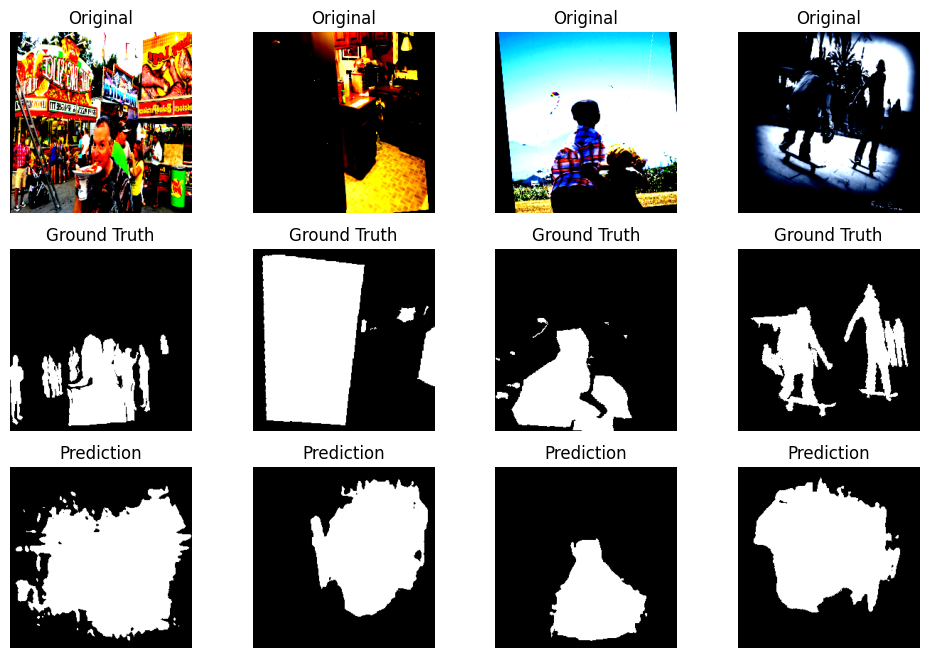

In [11]:
model.eval()
test_images, test_masks = next(iter(val_loader))
with torch.no_grad():
    outputs = model(test_images.to(device))
    preds = (torch.sigmoid(outputs) > 0.5).float().cpu()

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[i].permute(1, 2, 0).numpy())
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(3, 4, i + 5)
    plt.imshow(test_masks[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")
    
    plt.subplot(3, 4, i + 9)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis("off")
plt.show()
